**Title**: An image recognition system needs to classify handwritten digits (0-9) from the MNIST dataset using
Support Vector Machines (SVM).

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.decomposition import PCA


In [ ]:
train_df = pd.read_csv("mnist_train.csv")

In [ ]:
print(train_df.isnull().sum())


label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    1
28x25    1
28x26    1
28x27    1
28x28    1
Length: 785, dtype: int64


In [ ]:
train_df = train_df.fillna(0)


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
X = train_df.drop("label", axis=1).values
y = train_df["label"].values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:

pca = PCA(n_components=150)  # reduce 784 → 150
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)


PCA to reduce the original 784 features to 150 principal components, keeping most of the important information.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

A Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It works by finding the optimal hyperplane that best separates data points of different classes in a feature space. SVM tries to maximize the margin, which is the distance between the hyperplane and the nearest data points from each class (called support vectors)

In [ ]:
svm_linear = SVC(kernel='linear', C=0.1, random_state=42)



Support Vector Machine (SVM) classifier with a linear kernel, meaning it will try to find a straight hyperplane to separate the classes. The parameter C=0.1 controls regularization—lower values make the model more tolerant to misclassifications, helping prevent overfitting

In [ ]:
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

train_acc_linear = svm_linear.score(X_train, y_train)
print("Linear SVM Training Accuracy:", train_acc_linear)


Linear SVM Training Accuracy: 0.9673772389838589


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)


KFold CV divides the dataset into 5 equal parts, using 4 parts for training and 1 part for testing in each iteration. shuffle=True randomizes the data before splitting, and random_state=42

In [ ]:
# Linear Kernel
svm_linear = SVC(kernel="linear", C=10)
scores_linear = cross_val_score(svm_linear, X_train, y_train, cv=kf)
print("Linear Kernel CV Accuracy (each fold):", scores_linear)
print("Mean Linear Kernel Accuracy:", np.mean(scores_linear))


Linear Kernel CV Accuracy (each fold): [0.90398366 0.90057882 0.90330269 0.90497275 0.90905995]
Mean Linear Kernel Accuracy: 0.904379573217402


SVM has high training (96.7%) and cross-validation (90.4%) accuracy with a small difference, indicating good learning. The model is neither overfitting nor underfitting and generalizes well to unseen data.

In [ ]:

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

Linear Kernel Accuracy: 0.9299918278398257


In [ ]:
print("\nClassification Report (Linear SVM):\n", classification_report(y_test, y_pred_linear))



Classification Report (Linear SVM):
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       363
           1       0.96      0.98      0.97       419
           2       0.91      0.91      0.91       355
           3       0.91      0.93      0.92       384
           4       0.91      0.94      0.92       357
           5       0.89      0.88      0.88       323
           6       0.94      0.94      0.94       363
           7       0.94      0.95      0.95       387
           8       0.94      0.87      0.90       353
           9       0.92      0.90      0.91       367

    accuracy                           0.93      3671
   macro avg       0.93      0.93      0.93      3671
weighted avg       0.93      0.93      0.93      3671



A classification report is a summary of a classifier’s performance that includes key metrics such as precision, recall, F1-score, and support for each class.

Linear SVM achieves 93% accuracy overall, performing very well across most classes. Classes 5 and 8 show slightly lower scores, indicating minor misclassifications, but overall the model is balanced and reliable.

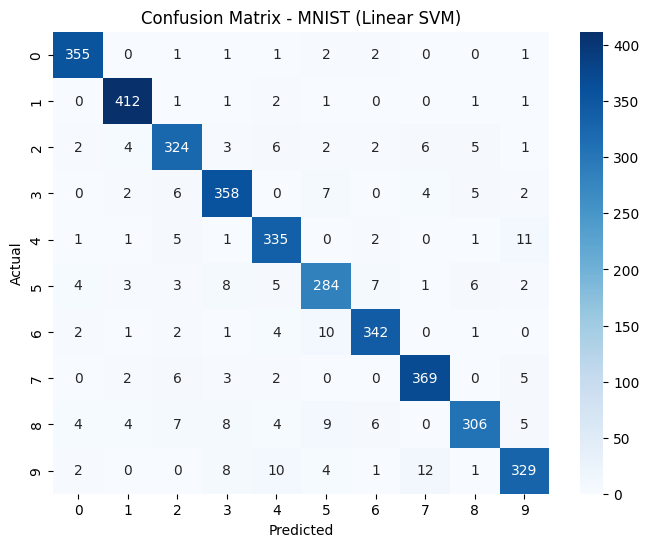

In [ ]:

cm = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix - MNIST (Linear SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Linear SVM does a very good job classifying most digits correctly, especially 0 and 1, which are almost never misclassified. Some digits that look similar, like 8, 9, 4, 5, 6, and 7, have a few mistakes—for example, 9 is sometimes predicted as 4 or 7, and 8 is sometimes predicted as 2 or 3